In [ ]:
# SECTION 1: INSTALL & IMPORTS
!pip install -q sentence-transformers datasets deep-translator transformers torch xgboost scikit-learn accelerate

import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset, Dataset
from deep_translator import GoogleTranslator

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier
from sentence_transformers import SentenceTransformer

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

import torch
from torch import nn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 4.2 MB/s eta 0:00:00


In [ ]:
# SECTION 2: CONSTANTS & LABEL MAP

# Sentence-BERT multilingual model, This model understands English, Greek, and Spanish natively.
# No translation needed for embedding generation.
SBERT_MODEL = "paraphrase-multilingual-mpnet-base-v2"

LABEL_MAP = {
    # Spanish labels → English
    "Finanzas":                   "Finance",
    "Industria":                  "Industry",
    "Tecnología":                 "Technology",
    "Gobierno y Control":         "Government & Controls",
    "Negocios y Gestión":         "Business & Management",
    "Impuestos y Contabilidad":   "Tax & Accounting",
    # Greek labels → English
    "Οικονομικά":                 "Finance",
    "Βιομηχανία":                 "Industry",
    "Τεχνολογία":                 "Technology",
    "Κυβέρνηση & Έλεγχοι":       "Government & Controls",
    "Επιχειρήσεις & Διοίκηση":   "Business & Management",
    "Φορολογία & Λογιστική":      "Tax & Accounting",
}

LANGUAGES = ['english', 'greek', 'spanish']

In [ ]:
# SECTION 3: HELPER FUNCTIONS
def clean_text(text):
    """
    Lowercases and removes non-alphabetic characters.
    Used for TF-IDF-style cleaning; for SBERT we keep
    punctuation since the model benefits from sentence structure.
    """
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def clean_text_sbert(text):
    """
    Light cleaning for SBERT — keeps punctuation and casing
    so the transformer can use full sentence structure.
    """
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text

def safe_translate_batch(texts, source_lang, batch_size=25, sleep_sec=1):
    """Translates a list of texts to English in batches with fallback."""
    translator = GoogleTranslator(source=source_lang, target="en")
    translated = []
    for i in range(0, len(texts), batch_size):
        batch = [str(x) if pd.notnull(x) else "" for x in texts[i:i+batch_size]]
        try:
            translated.extend(translator.translate_batch(batch))
        except Exception:
            for item in batch:
                try:
                    translated.append(translator.translate(item))
                except Exception:
                    translated.append(item)
        time.sleep(sleep_sec)
    return translated

def plot_confusion(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=labels, yticklabels=labels,
                cmap='Blues')
    plt.title(title, fontsize=13)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def print_section(title):
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")

In [ ]:
# SECTION 4: DATA LOADING
print_section("SECTION 4: DATA LOADING")

# English
english_df = pd.read_parquet("/content/test-00000-of-00001-c8868bee4bebb6d3.parquet")
english_df = english_df[['text', 'answer']].dropna().copy()
english_df['language'] = 'english'
print(f"English loaded: {len(english_df)} rows")
print(f"Columns: {english_df.columns.tolist()}")

# Greek
greek_ds  = load_dataset("TheFinAI/plutus-multifin")
greek_df  = pd.concat([greek_ds[s].to_pandas() for s in greek_ds.keys()], ignore_index=True)
greek_df  = greek_df[['text', 'answer']].dropna().copy()
greek_df['answer']   = greek_df['answer'].replace(LABEL_MAP)
greek_df['language'] = 'greek'
print(f"Greek loaded:   {len(greek_df)} rows")

# Spanish
spanish_ds = load_dataset("TheFinAI/flare-es-multifin")
spanish_df = pd.concat([spanish_ds[s].to_pandas() for s in spanish_ds.keys()], ignore_index=True)
spanish_df = spanish_df[['text', 'answer']].dropna().copy()
spanish_df['answer']   = spanish_df['answer'].replace(LABEL_MAP)
spanish_df['language'] = 'spanish'
print(f"Spanish loaded: {len(spanish_df)} rows")

print("\nSample English row:")
print(english_df.iloc[0])
print("\nSample Greek row:")
print(greek_df.iloc[0])
print("\nSample Spanish row:")
print(spanish_df.iloc[0])


  SECTION 4: DATA LOADING
English loaded: 546 rows
Columns: ['text', 'answer', 'language']


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/26.6k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/12.1k [00:00<?, ?B/s]

...

Greek loaded:   268 rows


README.md:   0%|          | 0.00/608 [00:00<?, ?B/s]

data/test-00000-of-00001-d50e1bf912331ee(…):   0%|          | 0.00/28.4k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/230 [00:00<?, ? examples/s]

Spanish loaded: 230 rows

Sample English row:
text        Deal summary Helen Oy / Infratek Finland Oy
answer                                          Finance
language                                        english
Name: 0, dtype: object

Sample Greek row:
text        Αναστολή συμβάσεων εργασίας Αυγούστου
answer                      Business & Management
language                                    greek
Name: 0, dtype: object

Sample Spanish row:
text        Gracias - Transporte y logística
answer                              Industry
language                             spanish
Name: 0, dtype: object


In [ ]:
# SECTION 5: DATA CLEANING
print_section("SECTION 5: DATA CLEANING")

def clean_df(df):
    """Remove nulls, duplicates, short texts, and normalize whitespace."""
    df = df.dropna(subset=['text', 'answer']).copy()
    df = df.drop_duplicates(subset=['text']).copy()
    # Remove rows with very short text (likely noise)
    df = df[df['text'].str.split().str.len() >= 3].copy()
    # Light clean for SBERT (keep punctuation and casing)
    df['text_clean'] = df['text'].apply(clean_text_sbert)
    df = df.reset_index(drop=True)
    return df

english_df = clean_df(english_df)
greek_df   = clean_df(greek_df)
spanish_df = clean_df(spanish_df)

print(f"After cleaning:")
print(f"  English: {len(english_df)} rows")
print(f"  Greek:   {len(greek_df)} rows")
print(f"  Spanish: {len(spanish_df)} rows")

# Check for null values
for name, df in [('English', english_df), ('Greek', greek_df), ('Spanish', spanish_df)]:
    nulls = df[['text', 'answer']].isnull().sum()
    print(f"\n{name} null counts:\n{nulls}")

language_dfs = {
    'english': english_df,
    'greek':   greek_df,
    'spanish': spanish_df
}


  SECTION 5: DATA CLEANING
After cleaning:
  English: 448 rows
  Greek:   235 rows
  Spanish: 203 rows

English null counts:
text      0
answer    0
dtype: int64

Greek null counts:
text      0
answer    0
dtype: int64

Spanish null counts:
text      0
answer    0
dtype: int64



  SECTION 6: EDA


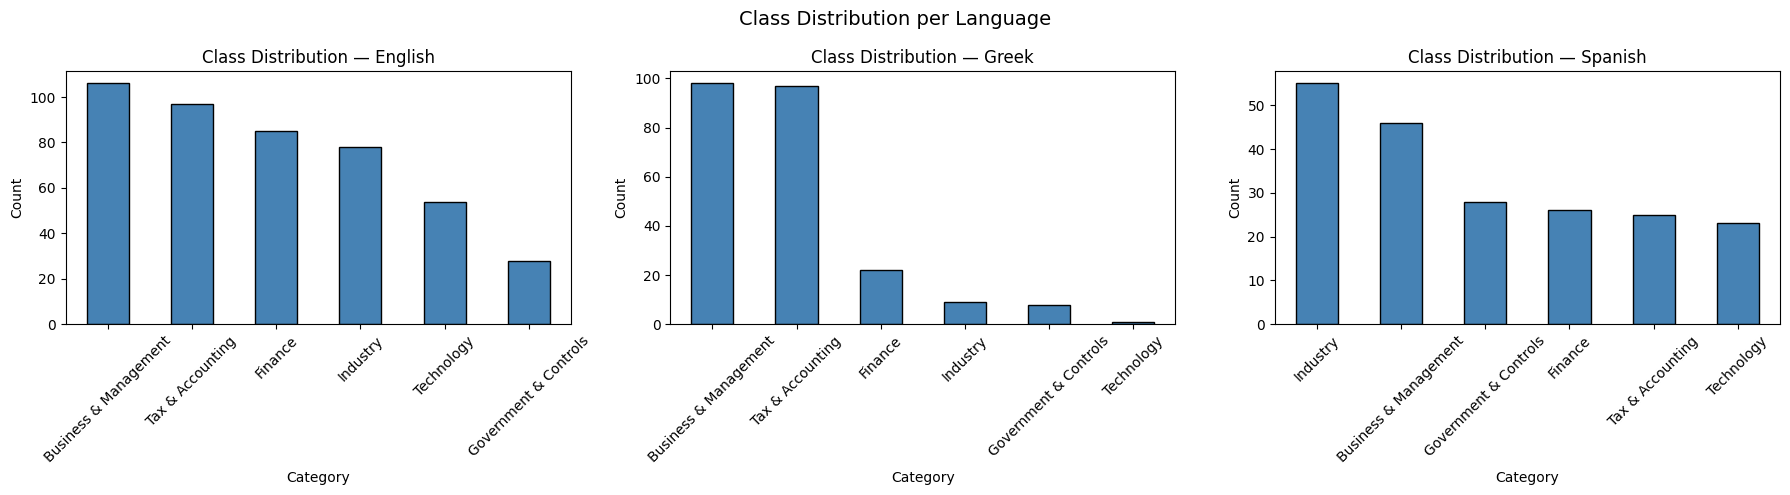

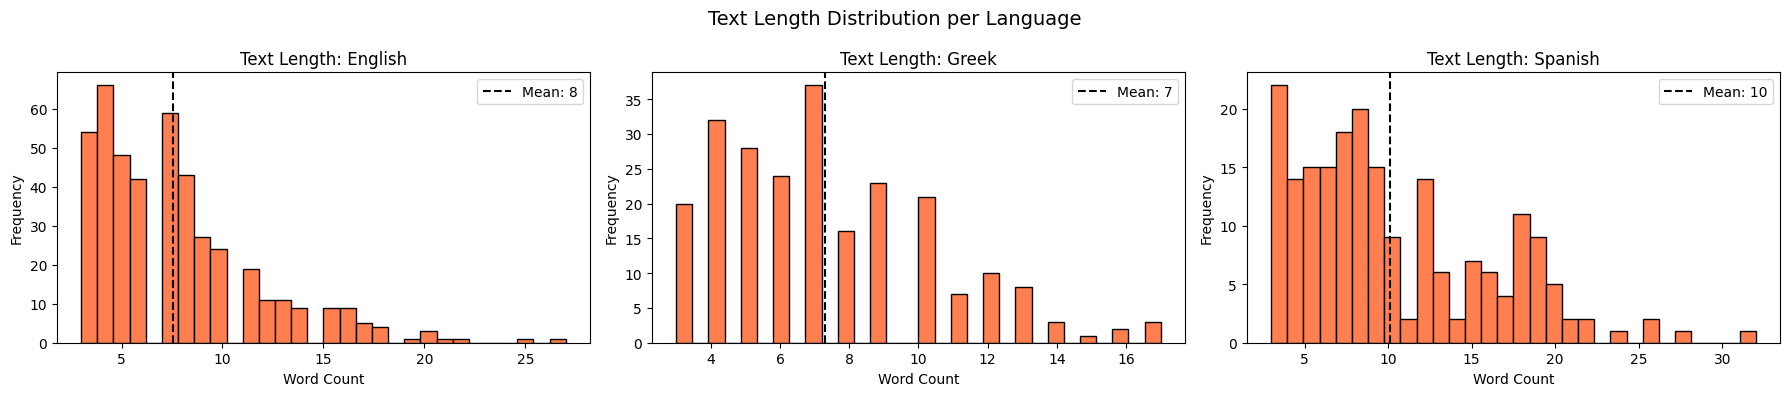

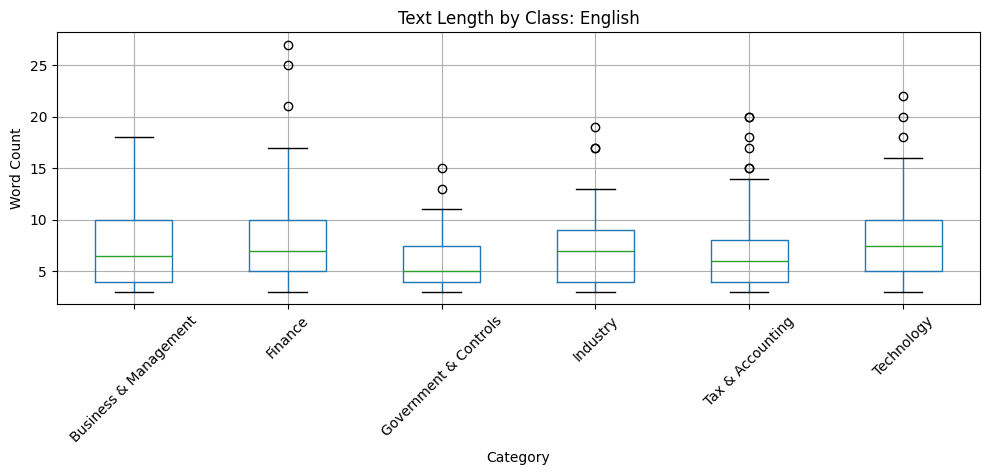

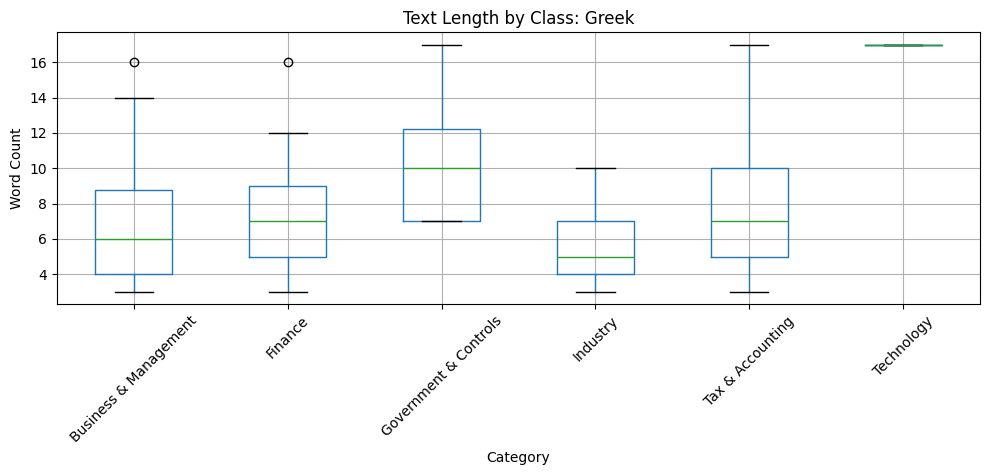

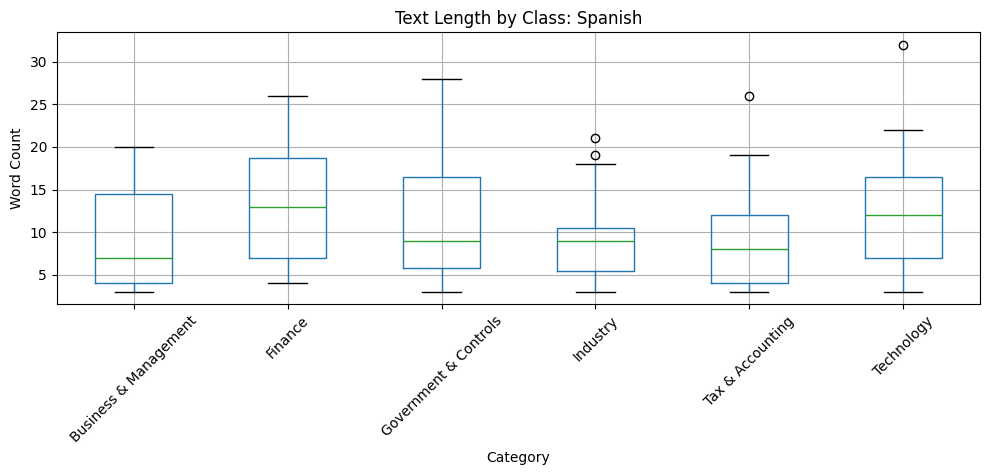

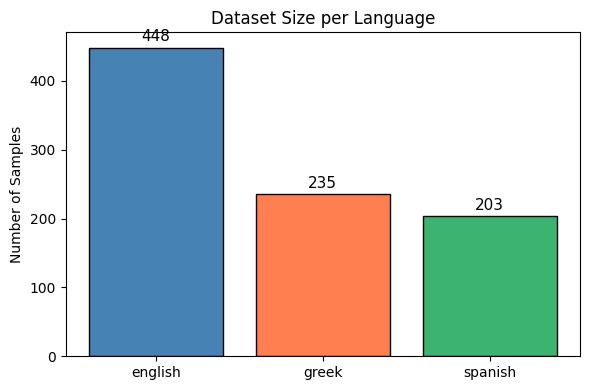


ENGLISH — Class distribution:
answer
Business & Management    106
Tax & Accounting          97
Finance                   85
Industry                  78
Technology                54
Government & Controls     28
Name: count, dtype: int64
answer
Business & Management    0.237
Tax & Accounting         0.217
Finance                  0.190
Industry                 0.174
Technology               0.121
Government & Controls    0.062
Name: proportion, dtype: float64

GREEK — Class distribution:
answer
Business & Management    98
Tax & Accounting         97
Finance                  22
Industry                  9
Government & Controls     8
Technology                1
Name: count, dtype: int64
answer
Business & Management    0.417
Tax & Accounting         0.413
Finance                  0.094
Industry                 0.038
Government & Controls    0.034
Technology               0.004
Name: proportion, dtype: float64

SPANISH — Class distribution:
answer
Industry                 55
Business & Man

In [ ]:
# SECTION 6: EXPLORATORY DATA ANALYSIS (EDA)
print_section("SECTION 6: EDA")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (lang, df) in zip(axes, language_dfs.items()):
    df['answer'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f"Class Distribution — {lang.capitalize()}", fontsize=12)
    ax.set_xlabel("Category")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)
plt.suptitle("Class Distribution per Language", fontsize=14)
plt.tight_layout()
plt.show()

# Text length distribution per language:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (lang, df) in zip(axes, language_dfs.items()):
    lengths = df['text_clean'].apply(lambda x: len(str(x).split()))
    ax.hist(lengths, bins=30, color='coral', edgecolor='black')
    ax.set_title(f"Text Length: {lang.capitalize()}")
    ax.set_xlabel("Word Count")
    ax.set_ylabel("Frequency")
    ax.axvline(lengths.mean(), color='black', linestyle='--', label=f"Mean: {lengths.mean():.0f}")
    ax.legend()
plt.suptitle("Text Length Distribution per Language", fontsize=14)
plt.tight_layout()
plt.show()

# Text length by class (box plot) per language:
for lang, df in language_dfs.items():
    df_plot = df.copy()
    df_plot['text_len'] = df_plot['text_clean'].apply(lambda x: len(str(x).split()))
    df_plot.boxplot(column='text_len', by='answer', figsize=(10, 5))
    plt.title(f"Text Length by Class: {lang.capitalize()}")
    plt.suptitle("")
    plt.xlabel("Category")
    plt.ylabel("Word Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Dataset size comparison:
sizes = {lang: len(df) for lang, df in language_dfs.items()}
plt.figure(figsize=(6, 4))
plt.bar(sizes.keys(), sizes.values(), color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='black')
plt.title("Dataset Size per Language")
plt.ylabel("Number of Samples")
for i, (k, v) in enumerate(sizes.items()):
    plt.text(i, v + 10, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

# Summary stats:
for lang, df in language_dfs.items():
    print(f"\n{lang.upper()} — Class distribution:")
    print(df['answer'].value_counts())
    print(df['answer'].value_counts(normalize=True).round(3))


  SECTION 7: SENTENCE-BERT EMBEDDINGS (FEATURE ENGINEERING)
Loading SBERT model: paraphrase-multilingual-mpnet-base-v2


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

  Embedding shape: (448, 768)  (samples × 768 dims)

Generating embeddings for GREEK (235 samples)...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

  Embedding shape: (235, 768)  (samples × 768 dims)

Generating embeddings for SPANISH (203 samples)...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

  Embedding shape: (203, 768)  (samples × 768 dims)

Visualizing embedding space PCA 2D: 


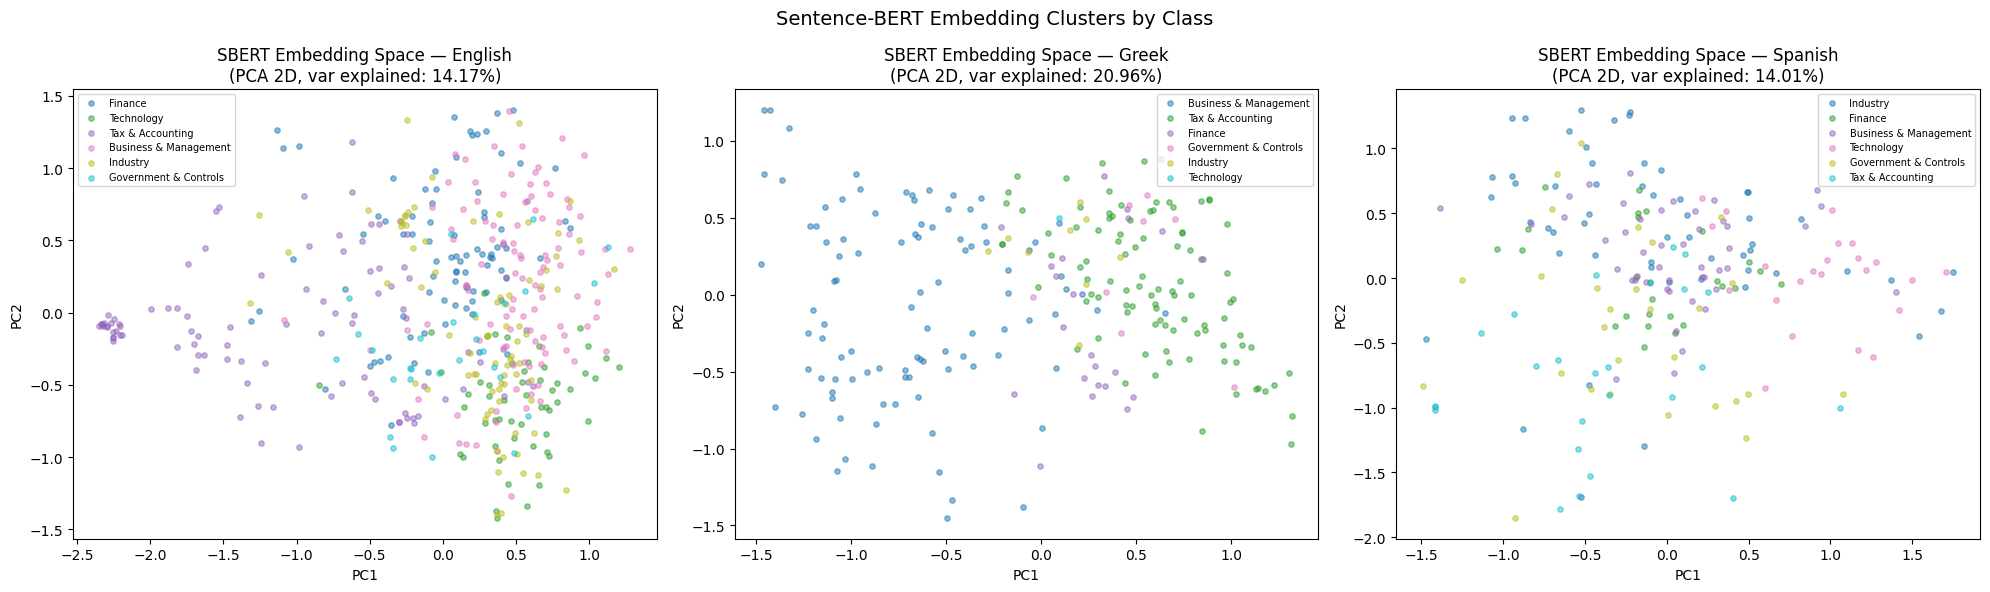

In [ ]:
# SECTION 7: SENTENCE-BERT EMBEDDINGS (FEATURE ENGINEERING)

# This is a better upgrade from TF-IDF where we use paraphrase-multilingual-mpnet-base-v2 supports 50+ languages.
# Each sentence becomes a 768-dimensional dense vector that captures semantic meaning — not just word counts.

print_section("SECTION 7: SENTENCE-BERT EMBEDDINGS (FEATURE ENGINEERING)")

print(f"Loading SBERT model: {SBERT_MODEL}")
sbert = SentenceTransformer(SBERT_MODEL)

embeddings = {}

for lang, df in language_dfs.items():
    print(f"\nGenerating embeddings for {lang.upper()} ({len(df)} samples)...")
    # encode() returns a numpy array of shape (n_samples, 768)
    # show_progress_bar=True prints a tqdm progress bar in Colab
    emb = sbert.encode(
        df['text_clean'].tolist(),
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True
    )
    embeddings[lang] = emb
    print(f"  Embedding shape: {emb.shape}  (samples × 768 dims)")

# Visualize embedding space with PCA:
# Well-separated clusters are nothing but embeddings are capturing class differences.
print("\nVisualizing embedding space PCA 2D: ")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (lang, df) in zip(axes, language_dfs.items()):
    emb = embeddings[lang]
    pca = PCA(n_components=2, random_state=42)
    reduced = pca.fit_transform(emb)

    classes = df['answer'].unique()
    colors  = plt.cm.tab10(np.linspace(0, 1, len(classes)))

    for cls, color in zip(classes, colors):
        mask = df['answer'] == cls
        ax.scatter(reduced[mask, 0], reduced[mask, 1],
                   label=cls, alpha=0.5, s=15, color=color)

    ax.set_title(f"SBERT Embedding Space — {lang.capitalize()}\n"
                 f"(PCA 2D, var explained: {pca.explained_variance_ratio_.sum():.2%})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(fontsize=7, loc='best')

plt.suptitle("Sentence-BERT Embedding Clusters by Class", fontsize=14)
plt.tight_layout()
plt.show()


Testing k values for ENGLISH...
  k= 50 | LR acc=0.611 f1=0.585 | XGB acc=0.667 f1=0.589
  k=100 | LR acc=0.711 f1=0.636 | XGB acc=0.689 f1=0.617
  k=150 | LR acc=0.733 f1=0.659 | XGB acc=0.711 f1=0.633
  k=200 | LR acc=0.756 f1=0.676 | XGB acc=0.722 f1=0.640
  k=250 | LR acc=0.800 f1=0.718 | XGB acc=0.722 f1=0.648
  k=300 | LR acc=0.789 f1=0.704 | XGB acc=0.756 f1=0.674
  k=400 | LR acc=0.767 f1=0.685 | XGB acc=0.700 f1=0.623
  k=500 | LR acc=0.800 f1=0.712 | XGB acc=0.733 f1=0.654
  k=600 | LR acc=0.778 f1=0.694 | XGB acc=0.733 f1=0.656
  k=768 | LR acc=0.778 f1=0.694 | XGB acc=0.756 f1=0.678

Testing k values for GREEK...
  k= 50 | LR acc=0.830 f1=0.699 | XGB acc=0.851 f1=0.689
  k=100 | LR acc=0.915 f1=0.884 | XGB acc=0.872 f1=0.698
  k=150 | LR acc=0.872 f1=0.715 | XGB acc=0.851 f1=0.623
  k=200 | LR acc=0.915 f1=0.884 | XGB acc=0.872 f1=0.694
  k=250 | LR acc=0.915 f1=0.884 | XGB acc=0.851 f1=0.623
  k=300 | LR acc=0.915 f1=0.830 | XGB acc=0.894 f1=0.737
  k=400 | LR acc=0.894 f

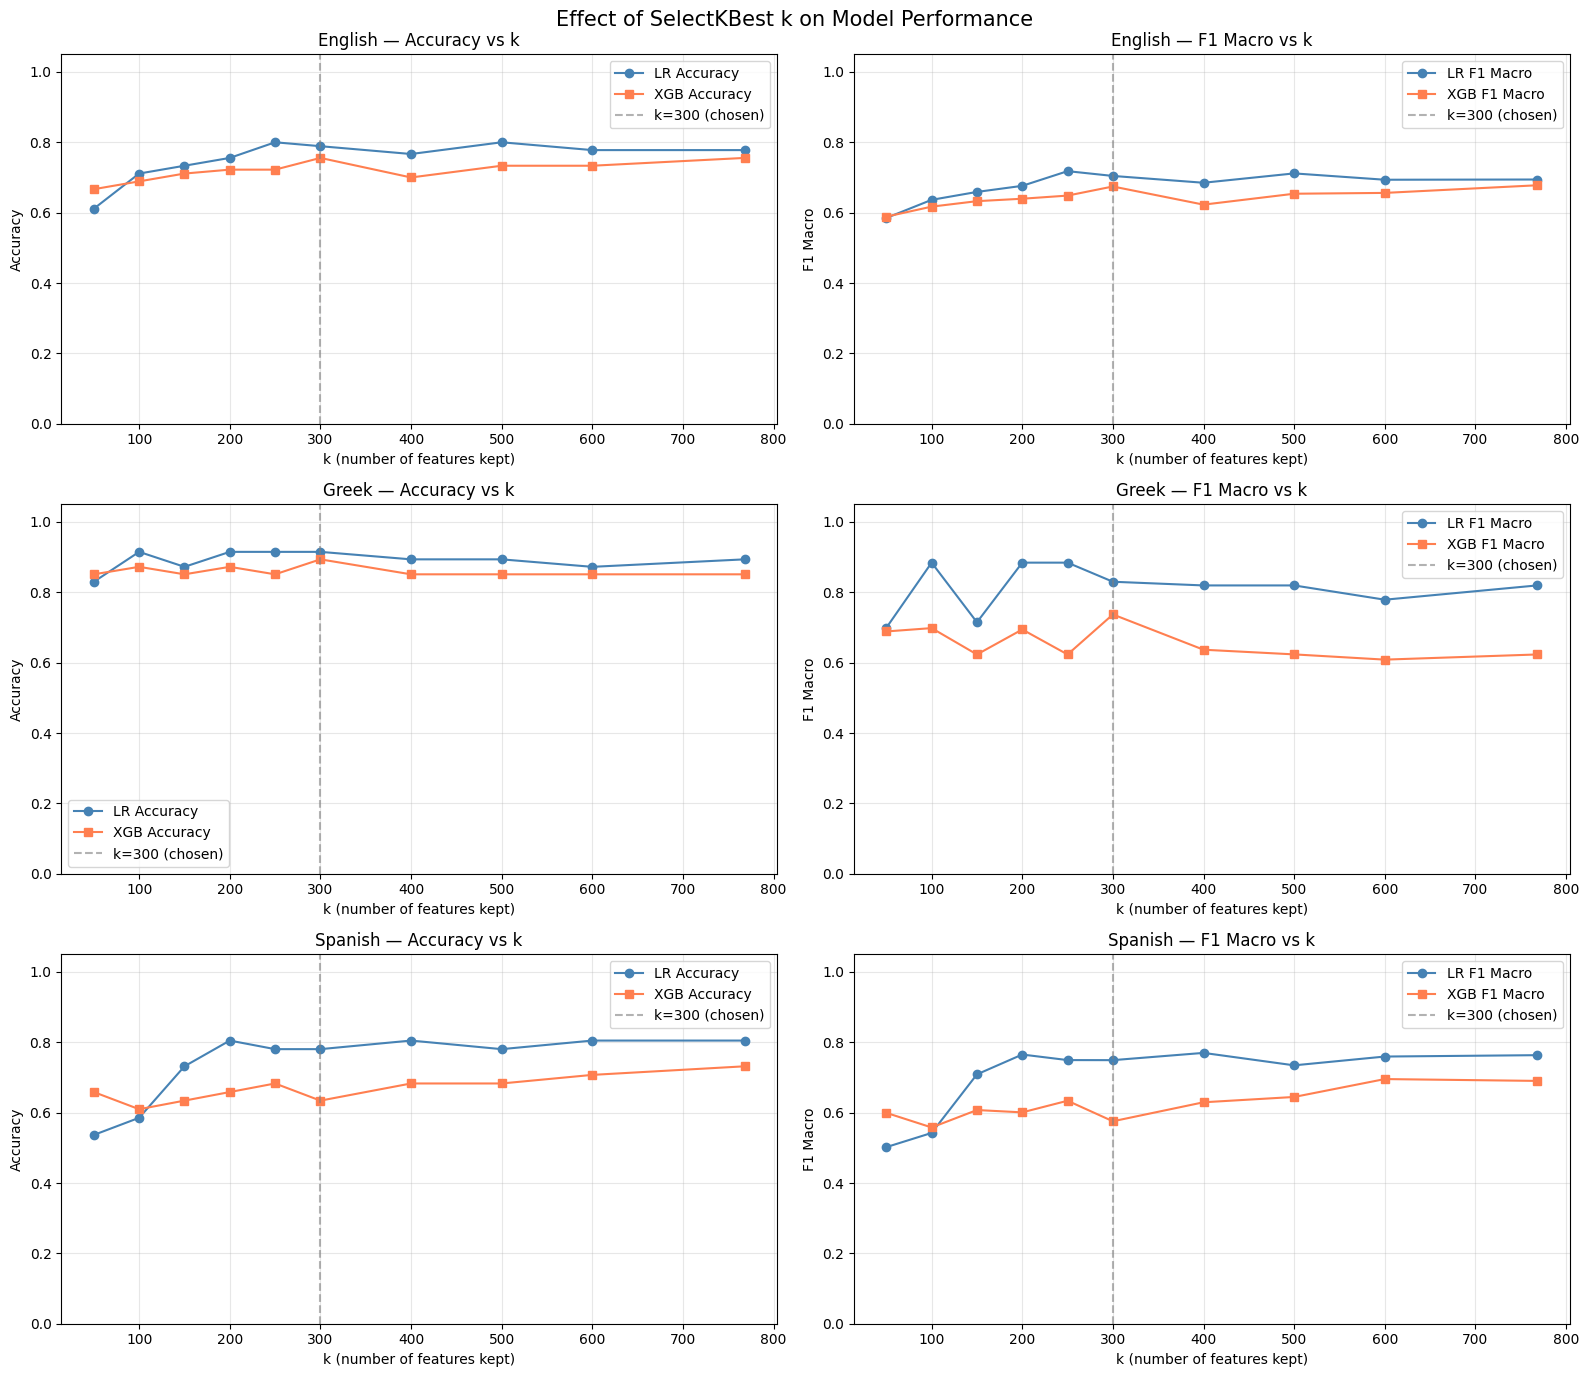


 BEST k PER LANGUAGE

ENGLISH
  LR  best accuracy → k=250  (0.800)
  LR  best F1 macro → k=250  (0.718)
  XGB best accuracy → k=300  (0.756)
  XGB best F1 macro → k=768  (0.678)

GREEK
  LR  best accuracy → k=100  (0.915)
  LR  best F1 macro → k=100  (0.884)
  XGB best accuracy → k=300  (0.894)
  XGB best F1 macro → k=300  (0.737)

SPANISH
  LR  best accuracy → k=200  (0.805)
  LR  best F1 macro → k=400  (0.770)
  XGB best accuracy → k=768  (0.732)
  XGB best F1 macro → k=600  (0.695)


In [ ]:
# EXPERIMENT: Effect of SelectKBest k on Model Performance

from sklearn.model_selection import cross_val_score

k_values = [50, 100, 150, 200, 250, 300, 400, 500, 600, 768]
# 768 = no selection, all dimensions kept

results_k = []

for lang in LANGUAGES:
    print(f"\nTesting k values for {lang.upper()}...")

    emb = embeddings[lang]
    df  = language_dfs[lang]

    # Same filtering as Section 8:
    le_temp = LabelEncoder()
    y_temp  = le_temp.fit_transform(df['answer'])
    class_counts  = pd.Series(y_temp).value_counts()
    valid_classes = class_counts[class_counts >= 2].index.tolist()
    mask          = pd.Series(y_temp).isin(valid_classes).values

    emb_f = emb[mask]
    df_f  = df.iloc[mask].reset_index(drop=True)
    le    = LabelEncoder()
    y_f   = le.fit_transform(df_f['answer'])

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        emb_f, y_f, test_size=0.2, random_state=42, stratify=y_f
    )

    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train_raw)
    X_te_sc = scaler.transform(X_test_raw)

    for k in k_values:
        k_actual = min(k, X_tr_sc.shape[1])  # cap at 768

        selector    = SelectKBest(score_func=f_classif, k=k_actual)
        X_tr_sel    = selector.fit_transform(X_tr_sc, y_train)
        X_te_sel    = selector.transform(X_te_sc)

        # Logistic Regression:
        lr = LogisticRegression(
            max_iter=2000, class_weight='balanced',
            C=2, solver='lbfgs', random_state=42
        )
        lr.fit(X_tr_sel, y_train)
        y_pred_lr = lr.predict(X_te_sel)

        acc_lr = accuracy_score(y_test, y_pred_lr)
        f1_lr  = f1_score(y_test, y_pred_lr, average='macro')

        # XGBoost:
        xgb = XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric='mlogloss', random_state=42
        )
        xgb.fit(X_tr_sel, y_train)
        y_pred_xgb = xgb.predict(X_te_sel)

        acc_xgb = accuracy_score(y_test, y_pred_xgb)
        f1_xgb  = f1_score(y_test, y_pred_xgb, average='macro')

        results_k.append({
            'language': lang, 'k': k_actual,
            'LR_acc':  acc_lr,  'LR_f1':  f1_lr,
            'XGB_acc': acc_xgb, 'XGB_f1': f1_xgb,
        })

        print(f"  k={k_actual:>3} | LR acc={acc_lr:.3f} f1={f1_lr:.3f} | "
              f"XGB acc={acc_xgb:.3f} f1={f1_xgb:.3f}")

df_k = pd.DataFrame(results_k)

# PLOT: Accuracy and F1 vs k — per language

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle("Effect of SelectKBest k on Model Performance", fontsize=15)

for row, lang in enumerate(LANGUAGES):
    sub = df_k[df_k['language'] == lang]

    # Accuracy plot
    ax_acc = axes[row, 0]
    ax_acc.plot(sub['k'], sub['LR_acc'],  marker='o', label='LR Accuracy',  color='steelblue')
    ax_acc.plot(sub['k'], sub['XGB_acc'], marker='s', label='XGB Accuracy', color='coral')
    ax_acc.axvline(x=300, color='gray', linestyle='--', alpha=0.6, label='k=300 (chosen)')
    ax_acc.set_title(f"{lang.capitalize()} — Accuracy vs k")
    ax_acc.set_xlabel("k (number of features kept)")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_ylim(0, 1.05)
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)

    # F1 plot
    ax_f1 = axes[row, 1]
    ax_f1.plot(sub['k'], sub['LR_f1'],  marker='o', label='LR F1 Macro',  color='steelblue')
    ax_f1.plot(sub['k'], sub['XGB_f1'], marker='s', label='XGB F1 Macro', color='coral')
    ax_f1.axvline(x=300, color='gray', linestyle='--', alpha=0.6, label='k=300 (chosen)')
    ax_f1.set_title(f"{lang.capitalize()} — F1 Macro vs k")
    ax_f1.set_xlabel("k (number of features kept)")
    ax_f1.set_ylabel("F1 Macro")
    ax_f1.set_ylim(0, 1.05)
    ax_f1.legend()
    ax_f1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# TABLE: Best k per language per model

print("\n BEST k PER LANGUAGE")
for lang in LANGUAGES:
    sub = df_k[df_k['language'] == lang]

    best_lr_acc  = sub.loc[sub['LR_acc'].idxmax()]
    best_lr_f1   = sub.loc[sub['LR_f1'].idxmax()]
    best_xgb_acc = sub.loc[sub['XGB_acc'].idxmax()]
    best_xgb_f1  = sub.loc[sub['XGB_f1'].idxmax()]

    print(f"\n{lang.upper()}")
    print(f"  LR  best accuracy → k={int(best_lr_acc['k'])}  ({best_lr_acc['LR_acc']:.3f})")
    print(f"  LR  best F1 macro → k={int(best_lr_f1['k'])}  ({best_lr_f1['LR_f1']:.3f})")
    print(f"  XGB best accuracy → k={int(best_xgb_acc['k'])}  ({best_xgb_acc['XGB_acc']:.3f})")
    print(f"  XGB best F1 macro → k={int(best_xgb_f1['k'])}  ({best_xgb_f1['XGB_f1']:.3f})")

In [ ]:
# SECTION 8: FEATURE SELECTION

# Even though SBERT gives us 768 good features we still need to do StandardScaler whcih normalizes feature scale,
# SelectKBest which keeps the top 300 dimensions most correlated with the class labels and reducing noise for LR/XGBoost.

print_section("SECTION 8: FEATURE SELECTION")

processed = {}

for lang, df in language_dfs.items():
    print(f"\nProcessing features for {lang.upper()}...")
    emb = embeddings[lang]

    le = LabelEncoder()
    y  = le.fit_transform(df['answer'])

    # if there are fewer than 2 samples then drop classes, This finds and removes those singleton classes before splitting.
    class_counts = pd.Series(y).value_counts()
    valid_classes = class_counts[class_counts >= 2].index.tolist()
    mask = pd.Series(y).isin(valid_classes).values

    if mask.sum() < len(y):
        removed = len(y) - mask.sum()
        print(f"  Removed {removed} sample(s) with singleton classes")

    emb_filtered = emb[mask]
    y_filtered   = y[mask]
    df_filtered  = df.iloc[mask].reset_index(drop=True)

    # Re-fit LabelEncoder on filtered labels so class indices are clean
    le = LabelEncoder()
    y_filtered = le.fit_transform(df_filtered['answer'])

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        emb_filtered, y_filtered,
        test_size=0.2, random_state=42, stratify=y_filtered
    )

    # Scale:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled  = scaler.transform(X_test_raw)

    # SelectKBest:
    k = min(250, X_train_scaled.shape[1])
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_sel = selector.fit_transform(X_train_scaled, y_train)
    X_test_sel  = selector.transform(X_test_scaled)

    print(f"  Samples after filtering: {len(y_filtered)}")
    print(f"  Classes: {le.classes_}")
    print(f"  Original dims:  768")
    print(f"  After SelectKBest (k={k}): {X_train_sel.shape[1]}")

    processed[lang] = {
        'X_train':   X_train_sel,
        'X_test':    X_test_sel,
        'y_train':   y_train,
        'y_test':    y_test,
        'le':        le,
        'train_idx': None,
        'test_idx':  None,
        'df':        df_filtered
    }

# Store train/test indices for FinBERT
for lang in LANGUAGES:
    data = processed[lang]
    df_f = data['df']
    le   = data['le']
    y    = le.transform(df_f['answer'])

    indices = np.arange(len(df_f))
    train_idx, test_idx = train_test_split(
        indices, test_size=0.2, random_state=42, stratify=y
    )
    processed[lang]['train_idx'] = train_idx
    processed[lang]['test_idx']  = test_idx


  SECTION 8: FEATURE SELECTION

Processing features for ENGLISH...
  Samples after filtering: 448
  Classes: ['Business & Management' 'Finance' 'Government & Controls' 'Industry'
 'Tax & Accounting' 'Technology']
  Original dims:  768
  After SelectKBest (k=250): 250

Processing features for GREEK...
  Removed 1 sample(s) with singleton classes
  Samples after filtering: 234
  Classes: ['Business & Management' 'Finance' 'Government & Controls' 'Industry'
 'Tax & Accounting']
  Original dims:  768
  After SelectKBest (k=250): 250

Processing features for SPANISH...
  Samples after filtering: 203
  Classes: ['Business & Management' 'Finance' 'Government & Controls' 'Industry'
 'Tax & Accounting' 'Technology']
  Original dims:  768
  After SelectKBest (k=250): 250


In [ ]:
# SECTION 8B: HYPERPARAMETER TUNING VIA GRIDSEARCHCV
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic regression : 24 combinations × 5 = 120 fits per language
lr_param_grid = {
    'C':        [0.1, 0.5, 1, 2, 5, 10],
    'solver':   ['lbfgs', 'saga'],
    'max_iter': [1000, 2000],
}

# XGBoost 24 combinations × 5 = 120 fits per language
xgb_param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 6],
    'learning_rate':    [0.05, 0.1],
    'subsample':        [0.8, 1.0],
}

best_params = {}

for lang in LANGUAGES:
    print(f"  LANGUAGE: {lang.upper()}")

    data = processed[lang]
    X_tr = data['X_train']
    y_tr = data['y_train']

    # LR GridSearch
    print(f"\n[LR GridSearch — {lang}]")
    lr_gs = GridSearchCV(
        LogisticRegression(class_weight='balanced', random_state=42),
        lr_param_grid,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )
    lr_gs.fit(X_tr, y_tr)
    best_params[f'{lang}_lr'] = lr_gs.best_params_
    print(f"  Best params : {lr_gs.best_params_}")
    print(f"  Best CV F1  : {lr_gs.best_score_:.4f}")

    # XGBoost GridSearch
    print(f"\n[XGB GridSearch — {lang}]")
    xgb_gs = GridSearchCV(
        XGBClassifier(
            eval_metric='mlogloss',
            colsample_bytree=0.8,
            random_state=42,
            use_label_encoder=False
        ),
        xgb_param_grid,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )
    xgb_gs.fit(X_tr, y_tr)
    best_params[f'{lang}_xgb'] = xgb_gs.best_params_
    print(f"  Best params : {xgb_gs.best_params_}")
    print(f"  Best CV F1  : {xgb_gs.best_score_:.4f}")

#Summary table
print("\n GRIDSEARCH BEST PARAMETERS SUMMARY")
print(f"{'Language':<10} {'Model':<8} {'Best Parameters'}")
print("-" * 80)
for lang in LANGUAGES:
    print(f"{lang:<10} {'LR':<8} {best_params[f'{lang}_lr']}")
    print(f"{lang:<10} {'XGB':<8} {best_params[f'{lang}_xgb']}")
    print()

  LANGUAGE: ENGLISH

[LR GridSearch — english]
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Best params : {'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}
  Best CV F1  : 0.8435

[XGB GridSearch — english]
Fitting 5 folds for each of 24 candidates, totalling 120 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:13:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Best params : {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
  Best CV F1  : 0.7423
  LANGUAGE: GREEK

[LR GridSearch — greek]
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Best params : {'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}
  Best CV F1  : 0.7055

[XGB GridSearch — greek]
Fitting 5 folds for each of 24 candidates, totalling 120 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:17:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Best params : {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 1.0}
  Best CV F1  : 0.6675
  LANGUAGE: SPANISH

[LR GridSearch — spanish]
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Best params : {'C': 0.5, 'max_iter': 1000, 'solver': 'lbfgs'}
  Best CV F1  : 0.7447

[XGB GridSearch — spanish]
Fitting 5 folds for each of 24 candidates, totalling 120 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:21:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Best params : {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
  Best CV F1  : 0.6803

 GRIDSEARCH BEST PARAMETERS SUMMARY
Language   Model    Best Parameters
--------------------------------------------------------------------------------
english    LR       {'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}
english    XGB      {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}

greek      LR       {'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}
greek      XGB      {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 1.0}

spanish    LR       {'C': 0.5, 'max_iter': 1000, 'solver': 'lbfgs'}
spanish    XGB      {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}



In [ ]:
# For each C value, Comparing Accuracy and F1 side by side.
from sklearn.model_selection import cross_val_score

print(f"Choosing the best C value by comparing accuracy and F1 score for logistic regression")

C_values = [0.1, 0.5, 1, 2, 5, 10]

for lang in LANGUAGES:
    data = processed[lang]
    X_tr = data['X_train']
    y_tr = data['y_train']
    lr_p = best_params[f'{lang}_lr']

    print(f"\nLanguage: {lang.upper()}")
    print(f"{'C Value':<12} {'CV Accuracy':<15} {'CV F1 Macro':<15} {'Note'}")

    for c in C_values:
        lr_temp = LogisticRegression(
            C=c,
            solver=lr_p['solver'],
            max_iter=lr_p['max_iter'],
            class_weight='balanced',
            random_state=42
        )
        f1  = cross_val_score(lr_temp, X_tr, y_tr, cv=cv, scoring='f1_macro',  n_jobs=-1).mean()
        acc = cross_val_score(lr_temp, X_tr, y_tr, cv=cv, scoring='accuracy',  n_jobs=-1).mean()
        note = "best" if c == lr_p['C'] else ""
        print(f"{str(c):<12} {acc:<15.4f} {f1:<15.4f} {note}")

Choosing the best C value by comparing accuracy and F1 score for logistic regression

Language: ENGLISH
C Value      CV Accuracy     CV F1 Macro     Note
0.1          0.8409          0.8307          
0.5          0.8381          0.8289          
1            0.8381          0.8240          
2            0.8409          0.8306          
5            0.8437          0.8369          
10           0.8521          0.8435          best

Language: GREEK
C Value      CV Accuracy     CV F1 Macro     Note
0.1          0.8661          0.6965          
0.5          0.8607          0.7041          
1            0.8661          0.7055          best
2            0.8661          0.7055          
5            0.8661          0.7054          
10           0.8661          0.6984          

Language: SPANISH
C Value      CV Accuracy     CV F1 Macro     Note
0.1          0.7716          0.7420          
0.5          0.7775          0.7447          best
1            0.7712          0.7346          
2       

In [ ]:
# For each XGBoost parameter, comparing Accuracy and F1 side by side.
print(f"Choosing the best parameters by comparing accuracy and F1 score for XG Boost")

n_estimators_values = [100, 200, 300]
max_depth_values    = [3, 6]
learning_rate_values = [0.05, 0.1]
subsample_values    = [0.8, 1.0]

for lang in LANGUAGES:
    data  = processed[lang]
    X_tr  = data['X_train']
    y_tr  = data['y_train']
    xgb_p = best_params[f'{lang}_xgb']

    print(f"\nLanguage: {lang.upper()}")

    # n_estimators
    print(f"\n  n_estimators (max_depth={xgb_p['max_depth']}, "
          f"lr={xgb_p['learning_rate']}, subsample={xgb_p['subsample']})")
    print(f"  {'n_estimators':<15} {'CV Accuracy':<15} {'CV F1 Macro':<15} {'Note'}")
    for n in n_estimators_values:
        xgb_temp = XGBClassifier(
            n_estimators=n,
            max_depth=xgb_p['max_depth'],
            learning_rate=xgb_p['learning_rate'],
            subsample=xgb_p['subsample'],
            colsample_bytree=0.8,
            eval_metric='mlogloss',
            random_state=42,
            use_label_encoder=False
        )
        f1  = cross_val_score(xgb_temp, X_tr, y_tr, cv=cv, scoring='f1_macro',  n_jobs=-1).mean()
        acc = cross_val_score(xgb_temp, X_tr, y_tr, cv=cv, scoring='accuracy',  n_jobs=-1).mean()
        note = "best" if n == xgb_p['n_estimators'] else ""
        print(f"  {str(n):<15} {acc:<15.4f} {f1:<15.4f} {note}")

    # max_depth
    print(f"\n  max_depth (n_estimators={xgb_p['n_estimators']}, "
          f"lr={xgb_p['learning_rate']}, subsample={xgb_p['subsample']})")
    print(f"  {'max_depth':<15} {'CV Accuracy':<15} {'CV F1 Macro':<15} {'Note'}")
    for d in max_depth_values:
        xgb_temp = XGBClassifier(
            n_estimators=xgb_p['n_estimators'],
            max_depth=d,
            learning_rate=xgb_p['learning_rate'],
            subsample=xgb_p['subsample'],
            colsample_bytree=0.8,
            eval_metric='mlogloss',
            random_state=42,
            use_label_encoder=False
        )
        f1  = cross_val_score(xgb_temp, X_tr, y_tr, cv=cv, scoring='f1_macro',  n_jobs=-1).mean()
        acc = cross_val_score(xgb_temp, X_tr, y_tr, cv=cv, scoring='accuracy',  n_jobs=-1).mean()
        note = "best" if d == xgb_p['max_depth'] else ""
        print(f"  {str(d):<15} {acc:<15.4f} {f1:<15.4f} {note}")

    # learning_rate
    print(f"\n  learning_rate (n_estimators={xgb_p['n_estimators']}, "
          f"max_depth={xgb_p['max_depth']}, subsample={xgb_p['subsample']})")
    print(f"  {'learning_rate':<15} {'CV Accuracy':<15} {'CV F1 Macro':<15} {'Note'}")
    for lr in learning_rate_values:
        xgb_temp = XGBClassifier(
            n_estimators=xgb_p['n_estimators'],
            max_depth=xgb_p['max_depth'],
            learning_rate=lr,
            subsample=xgb_p['subsample'],
            colsample_bytree=0.8,
            eval_metric='mlogloss',
            random_state=42,
            use_label_encoder=False
        )
        f1  = cross_val_score(xgb_temp, X_tr, y_tr, cv=cv, scoring='f1_macro',  n_jobs=-1).mean()
        acc = cross_val_score(xgb_temp, X_tr, y_tr, cv=cv, scoring='accuracy',  n_jobs=-1).mean()
        note = "best" if lr == xgb_p['learning_rate'] else ""
        print(f"  {str(lr):<15} {acc:<15.4f} {f1:<15.4f} {note}")

    # subsample
    print(f"\n  subsample (n_estimators={xgb_p['n_estimators']}, "
          f"max_depth={xgb_p['max_depth']}, lr={xgb_p['learning_rate']})")
    print(f"  {'subsample':<15} {'CV Accuracy':<15} {'CV F1 Macro':<15} {'Note'}")
    for s in subsample_values:
        xgb_temp = XGBClassifier(
            n_estimators=xgb_p['n_estimators'],
            max_depth=xgb_p['max_depth'],
            learning_rate=xgb_p['learning_rate'],
            subsample=s,
            colsample_bytree=0.8,
            eval_metric='mlogloss',
            random_state=42,
            use_label_encoder=False
        )
        f1  = cross_val_score(xgb_temp, X_tr, y_tr, cv=cv, scoring='f1_macro',  n_jobs=-1).mean()
        acc = cross_val_score(xgb_temp, X_tr, y_tr, cv=cv, scoring='accuracy',  n_jobs=-1).mean()
        note = "best" if s == xgb_p['subsample'] else ""
        print(f"  {str(s):<15} {acc:<15.4f} {f1:<15.4f} {note}")

In [ ]:
# SECTION 9: MODEL TRAINING & EVALUATION
# Logistic Regression and XGBoost based on SBERT embeddings
lr_xgb_results = []

for lang in LANGUAGES:
    data  = processed[lang]
    le    = data['le']
    X_tr  = data['X_train']
    X_te  = data['X_test']
    y_tr  = data['y_train']
    y_te  = data['y_test']
    lr_p  = best_params[f'{lang}_lr']
    xgb_p = best_params[f'{lang}_xgb']

    print(f"\n--- {lang.upper()} ---")
    print(f"  Train: {len(y_tr)} | Test: {len(y_te)} | Classes: {le.classes_}")

    # Logistic Regression using best params from GridSearch
    lr = LogisticRegression(
        C=lr_p['C'],
        solver=lr_p['solver'],
        max_iter=lr_p['max_iter'],
        class_weight='balanced',
        random_state=42
    )
    lr.fit(X_tr, y_tr)
    y_pred_lr = lr.predict(X_te)

    acc_lr = accuracy_score(y_te, y_pred_lr)
    f1_lr  = f1_score(y_te, y_pred_lr, average='macro')

    print(f"\n[LR — {lang}]  Accuracy: {acc_lr:.4f}  |  F1 Macro: {f1_lr:.4f}")
    print(classification_report(y_te, y_pred_lr, target_names=le.classes_))
    plot_confusion(y_te, y_pred_lr, le.classes_, f"LR — {lang.capitalize()}")

    lr_xgb_results.append({
        'language': lang,
        'model':    'Logistic Regression',
        'accuracy': acc_lr,
        'f1_macro': f1_lr
    })

    # XGBoost using best params from GridSearch
    xgb = XGBClassifier(
        n_estimators=xgb_p['n_estimators'],
        max_depth=xgb_p['max_depth'],
        learning_rate=xgb_p['learning_rate'],
        subsample=xgb_p['subsample'],
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42,
        use_label_encoder=False
    )
    xgb.fit(X_tr, y_tr)
    y_pred_xgb = xgb.predict(X_te)

    acc_xgb = accuracy_score(y_te, y_pred_xgb)
    f1_xgb  = f1_score(y_te, y_pred_xgb, average='macro')

    print(f"\n[XGB — {lang}]  Accuracy: {acc_xgb:.4f}  |  F1 Macro: {f1_xgb:.4f}")
    print(classification_report(y_te, y_pred_xgb, target_names=le.classes_))
    plot_confusion(y_te, y_pred_xgb, le.classes_, f"XGBoost — {lang.capitalize()}")

    lr_xgb_results.append({
        'language': lang,
        'model':    'XGBoost',
        'accuracy': acc_xgb,
        'f1_macro': f1_xgb
    })

lr_xgb_summary = pd.DataFrame(lr_xgb_results)
print("\nLR and XGBoost Summary")
print(lr_xgb_summary.to_string(index=False))

In [ ]:
# SECTION 9B: FINBERT FINE-TUNING per language.
# FinBERT works on direct raw text directly, hence no SBERT embeddings needed.
# Also, The WeightedTrainer handles class imbalance via CrossEntropyLoss.

print_section("SECTION 9B: FINBERT (Per Language)")

finbert_results = []

def run_finbert_for_language(lang, df, train_idx, test_idx, le):
    print(f"\n FinBERT: {lang.upper()}")

    train_df = df.iloc[train_idx][['text_clean', 'answer']].copy()
    test_df  = df.iloc[test_idx][['text_clean', 'answer']].copy()

    train_df = train_df.rename(columns={'text_clean': 'text'})
    test_df  = test_df.rename(columns={'text_clean': 'text'})

    train_df['label'] = le.transform(train_df['answer'])
    test_df['label']  = le.transform(test_df['answer'])

    num_classes = len(le.classes_)

    # Tokenize
    model_name = "ProsusAI/finbert"
    tokenizer  = AutoTokenizer.from_pretrained(model_name)
    model      = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_classes,
        ignore_mismatched_sizes=True
    )

    def tokenize(example):
        return tokenizer(
            example['text'],
            truncation=True,
            padding='max_length',
            max_length=256
        )

    train_hf = Dataset.from_pandas(train_df[['text', 'label']].reset_index(drop=True))
    test_hf  = Dataset.from_pandas(test_df[['text', 'label']].reset_index(drop=True))

    train_hf = train_hf.map(tokenize, batched=True)
    test_hf  = test_hf.map(tokenize, batched=True)

    train_hf.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
    test_hf.set_format(type='torch',  columns=['input_ids', 'attention_mask', 'label'])

    # Class weights
    cw = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_df['label']),
        y=train_df['label'].values
    )
    cw_tensor = torch.tensor(cw, dtype=torch.float)

    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels  = inputs.get('labels')
            outputs = model(**inputs)
            logits  = outputs.get('logits')
            loss_fn = nn.CrossEntropyLoss(weight=cw_tensor.to(model.device))
            loss    = loss_fn(logits, labels)
            return (loss, outputs) if return_outputs else loss

    training_args = TrainingArguments(
        output_dir=f"./finbert_{lang}",
        eval_strategy='epoch',
        save_strategy='epoch',
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=5,
        load_best_model_at_end=True,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_steps=50,
        report_to='none'
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)
        return {
            'accuracy': accuracy_score(labels, preds),
            'f1_macro': f1_score(labels, preds, average='macro')
        }

    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_hf,
        eval_dataset=test_hf,
        compute_metrics=compute_metrics
    )

    trainer.train()
    results = trainer.evaluate()

    acc = results['eval_accuracy']
    f1  = results['eval_f1_macro']
    print(f"\n[FinBERT - {lang}]  Accuracy: {acc:.4f}  |  F1 Macro: {f1:.4f}")

    preds_out = trainer.predict(test_hf)
    y_true    = preds_out.label_ids
    y_pred    = preds_out.predictions.argmax(axis=1)
    print(classification_report(y_true, y_pred, target_names=le.classes_))
    plot_confusion(y_true, y_pred, le.classes_, f"FinBERT — {lang.capitalize()}")

    return {'language': lang, 'model': 'FinBERT', 'accuracy': acc, 'f1_macro': f1}

for lang in LANGUAGES:
    data = processed[lang]
    res  = run_finbert_for_language(
        lang,
        data['df'],
        data['train_idx'],
        data['test_idx'],
        data['le']
    )
    finbert_results.append(res)

finbert_summary = pd.DataFrame(finbert_results)
print("\n FinBERT Summary: ")
print(finbert_summary.to_string(index=False))

In [ ]:
# SECTION 10: FINAL RESULTS SUMMARY + CHARTS
print_section("SECTION 10: FINAL RESULTS")

final_summary = pd.concat([lr_xgb_summary, finbert_summary], ignore_index=True)
final_summary = final_summary.sort_values(['language', 'model']).reset_index(drop=True)

print("\n ALL MODELS vs ALL LANGUAGES")
print(final_summary.to_string(index=False))

# --- Accuracy chart ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
model_colors = {'Logistic Regression': 'steelblue', 'XGBoost': 'coral', 'FinBERT': 'mediumseagreen'}

for ax, lang in zip(axes, LANGUAGES):
    subset = final_summary[final_summary['language'] == lang]
    bars   = ax.bar(subset['model'], subset['accuracy'],
                    color=[model_colors[m] for m in subset['model']],
                    edgecolor='black')
    ax.set_title(f"{lang.capitalize()}", fontsize=13)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Model")
    ax.tick_params(axis='x', rotation=20)
    if ax == axes[0]:
        ax.set_ylabel("Accuracy")
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01,
                f"{yval:.3f}", ha='center', fontsize=9)

plt.suptitle("Accuracy: All Models vs All Languages (SBERT Embeddings and GridSearch Tuned)", fontsize=14)
plt.tight_layout()
plt.show()

# --- F1 Macro chart ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, lang in zip(axes, LANGUAGES):
    subset = final_summary[final_summary['language'] == lang]
    bars   = ax.bar(subset['model'], subset['f1_macro'],
                    color=[model_colors[m] for m in subset['model']],
                    edgecolor='black')
    ax.set_title(f"{lang.capitalize()}", fontsize=13)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Model")
    ax.tick_params(axis='x', rotation=20)
    if ax == axes[0]:
        ax.set_ylabel("F1 Macro")
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01,
                f"{yval:.3f}", ha='center', fontsize=9)

plt.suptitle("F1 Macro: All Models vs All Languages (SBERT Embeddings and GridSearch Tuned)", fontsize=14)
plt.tight_layout()
plt.show()

# --- Heatmap: best model per language ---
pivot_acc = final_summary.pivot(index='model', columns='language', values='accuracy')
pivot_f1  = final_summary.pivot(index='model', columns='language', values='f1_macro')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(pivot_acc, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[0], vmin=0, vmax=1)
axes[0].set_title("Accuracy Heatmap")
sns.heatmap(pivot_f1,  annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("F1 Macro Heatmap")
plt.suptitle("Model vs Language Performance based on SBERT Embeddings", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# SECTION 11: DEMO TEST
# Type any financial headline and get predictions from all models
print_section("SECTION 11: DEMO TEST")

# Re-train one final LR and XGBoost on the full English dataset
print("Preparing demo models on English data...")

eng_data = processed['english']

# using best params from GridSearch for English
eng_lr_p  = best_params['english_lr']
eng_xgb_p = best_params['english_xgb']

demo_lr = LogisticRegression(
    C=eng_lr_p['C'],
    solver=eng_lr_p['solver'],
    max_iter=eng_lr_p['max_iter'],
    class_weight='balanced',
    random_state=42
)
demo_lr.fit(eng_data['X_train'], eng_data['y_train'])

demo_xgb = XGBClassifier(
    n_estimators=eng_xgb_p['n_estimators'],
    max_depth=eng_xgb_p['max_depth'],
    learning_rate=eng_xgb_p['learning_rate'],
    subsample=eng_xgb_p['subsample'],
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    use_label_encoder=False
)
demo_xgb.fit(eng_data['X_train'], eng_data['y_train'])

demo_le      = eng_data['le']
demo_scaler  = StandardScaler().fit(embeddings['english'])
demo_selector = SelectKBest(score_func=f_classif, k=250)
demo_selector.fit(demo_scaler.transform(embeddings['english']), demo_le.transform(language_dfs['english']['answer']))

def predict_text(text):
    """
    Takes a raw financial headline/sentence and returns
    predicted category from LR, XGBoost (SBERT embeddings).
    """
    print(f"\nInput text: \"{text}\"")
    print("-" * 50)

    # Generate SBERT embedding
    emb      = sbert.encode([text], convert_to_numpy=True)
    emb_sc   = demo_scaler.transform(emb)
    emb_sel  = demo_selector.transform(emb_sc)

    # LR prediction
    pred_lr     = demo_lr.predict(emb_sel)[0]
    prob_lr     = demo_lr.predict_proba(emb_sel)[0]
    label_lr    = demo_le.inverse_transform([pred_lr])[0]
    conf_lr     = prob_lr.max()

    # XGBoost prediction
    pred_xgb    = demo_xgb.predict(emb_sel)[0]
    prob_xgb    = demo_xgb.predict_proba(emb_sel)[0]
    label_xgb   = demo_le.inverse_transform([pred_xgb])[0]
    conf_xgb    = prob_xgb.max()

    print(f"  Logistic Regression → {label_lr:<30} (confidence: {conf_lr:.2%})")
    print(f"  XGBoost             → {label_xgb:<30} (confidence: {conf_xgb:.2%})")

    # Show top 3 probabilities for LR
    top3_idx = np.argsort(prob_lr)[::-1][:3]
    print(f"\n  LR Top-3 probabilities:")
    for idx in top3_idx:
        print(f"    {demo_le.inverse_transform([idx])[0]:<30}: {prob_lr[idx]:.2%}")

    # Show top 3 probabilities for XGB
    top3_idx = np.argsort(prob_xgb)[::-1][:3]
    print(f"\n  XGB Top-3 probabilities:")
    for idx in top3_idx:
        print(f"    {demo_le.inverse_transform([idx])[0]:<30}: {prob_xgb[idx]:.2%}")

# Run demo on several financial headlines
demo_texts = [
    "Apple reports record quarterly revenue driven by iPhone sales",
    "Government introduces new tax reform bill affecting corporations",
    "Central bank raises interest rates to combat inflation",
    "Tech startup secures Series B funding for AI development",
    "New regulations proposed for financial derivatives market",
    "Manufacturing output declines amid supply chain disruptions",
]

print("\nRunning demo predictions on financial headlines:\n")
for text in demo_texts:
    predict_text(text)

#Interactive demo cell with run this separately in Colab
print("  INTERACTIVE DEMO — run this cell in Colab:")
print("""
user_input = input("Enter a financial headline: ")
predict_text(user_input)
""")

In [ ]:
# SECTION 12: DEMO WITH GROUND TRUTH (from actual test set)

data     = processed['english']
le       = data['le']
X_te     = data['X_test']
y_te     = data['y_test']
df_eng   = data['df']

test_idx = processed['english']['test_idx']
test_df  = df_eng.iloc[test_idx].reset_index(drop=True)
test_df['true_label'] = le.inverse_transform(y_te)

sample_rows = (
    test_df.groupby('true_label', group_keys=False)
           .apply(lambda x: x.sample(1, random_state=42))
           .reset_index(drop=True)
)

print("=" * 65)
print("  DEMO: Real Test Samples with Ground Truth vs Predictions")
print("=" * 65)

results_demo = []

for _, row in sample_rows.iterrows():
    text       = row['text_clean']
    true_label = row['true_label']

    emb     = sbert.encode([text], convert_to_numpy=True)
    emb_sc  = demo_scaler.transform(emb)
    emb_sel = demo_selector.transform(emb_sc)

    pred_lr   = demo_lr.predict(emb_sel)[0]
    prob_lr   = demo_lr.predict_proba(emb_sel)[0]
    label_lr  = demo_le.inverse_transform([pred_lr])[0]
    conf_lr   = prob_lr.max()

    pred_xgb  = demo_xgb.predict(emb_sel)[0]
    prob_xgb  = demo_xgb.predict_proba(emb_sel)[0]
    label_xgb = demo_le.inverse_transform([pred_xgb])[0]
    conf_xgb  = prob_xgb.max()

    lr_correct  = "correct" if label_lr  == true_label else "wrong"
    xgb_correct = "correct" if label_xgb == true_label else "wrong"

    print(f"\nText        : {text[:90]}{'...' if len(text)>90 else ''}")
    print(f"Ground Truth: {true_label}")
    print(f"LR          : {label_lr:<28} (conf: {conf_lr:.2%})  {lr_correct}")
    print(f"XGBoost     : {label_xgb:<28} (conf: {conf_xgb:.2%})  {xgb_correct}")
    print("-" * 65)

    results_demo.append({
        'text':         text[:80],
        'ground_truth': true_label,
        'LR_pred':      label_lr,
        'LR_correct':   lr_correct,
        'XGB_pred':     label_xgb,
        'XGB_correct':  xgb_correct,
    })

demo_summary = pd.DataFrame(results_demo)
print("\nDEMO SUMMARY TABLE")
print(demo_summary[['ground_truth','LR_pred','LR_correct','XGB_pred','XGB_correct']].to_string(index=False))

lr_score  = sum(1 for r in results_demo if r['LR_correct']  == 'correct')
xgb_score = sum(1 for r in results_demo if r['XGB_correct'] == 'correct')
total     = len(results_demo)

plt.figure(figsize=(5, 4))
plt.bar(['Logistic Regression', 'XGBoost'],
        [lr_score, xgb_score],
        color=['steelblue', 'coral'], edgecolor='black')
plt.title(f"Demo Accuracy: Correct out of {total} (one per class)")
plt.ylabel("Correct Predictions")
plt.ylim(0, total + 0.5)
for i, v in enumerate([lr_score, xgb_score]):
    plt.text(i, v + 0.05, f"{v}/{total}", ha='center', fontsize=12)
plt.tight_layout()
plt.show()

NameError: name 'processed' is not defined